In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

/Users/pranavsbharadwaj/forecast_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
file_path = "/Users/pranavsbharadwaj/Desktop/business_suite_datasets/retail_store_inventory.csv"   # 👈 CHANGE THIS

df = pd.read_csv(file_path)

print(df.head())
print("\nColumns:", df.columns)

         Date Store ID Product ID     Category Region  Inventory Level  \
0  01-01-2022     S001      P0001    Groceries  North              231   
1  01-01-2022     S001      P0002         Toys  South              204   
2  01-01-2022     S001      P0003         Toys   West              102   
3  01-01-2022     S001      P0004         Toys  North              469   
4  01-01-2022     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Price  Discount Weather Condition  \
0         127             55  33.50        20             Rainy   
1         150             66  63.01        20             Sunny   
2          65             51  27.99        10             Sunny   
3          61            164  32.72        10            Cloudy   
4          14            135  73.64         0             Sunny   

   Holiday/Promotion  Competitor Pricing Seasonality  
0                  0               29.69      Autumn  
1                  0               66.16  

In [3]:
df['Sales'] = df['Units Sold'] * df['Price']

print(df[['Units Sold', 'Price', 'Sales']].head())

   Units Sold  Price    Sales
0         127  33.50  4254.50
1         150  63.01  9451.50
2          65  27.99  1819.35
3          61  32.72  1995.92
4          14  73.64  1030.96


In [7]:
def detect_date_column(df):
    for col in df.columns:
        col_lower = col.lower()
        
        # Priority: column name contains date/time keywords
        if any(keyword in col_lower for keyword in ['date', 'time', 'day']):
            return col
        
    # Fallback: try parsing
    for col in df.columns:
        try:
            parsed = pd.to_datetime(df[col], errors='coerce')
            
            # At least 80% values should be valid dates
            if parsed.notna().sum() > len(df) * 0.8:
                return col
        except:
            continue
            
    return None

In [8]:
date_col = detect_date_column(df)
target_col = detect_target_column(df)

print("Detected Date Column:", date_col)
print("Detected Target Column:", target_col)

Detected Date Column: Date
Detected Target Column: Sales


In [39]:
def run_forecast_pipeline(file_path):

    import pandas as pd
    import numpy as np
    from statsmodels.tsa.arima.model import ARIMA
    from prophet import Prophet
    from xgboost import XGBRegressor

    # Load data
    df = pd.read_csv(file_path)

    # Create Sales if not present
    if 'Sales' not in df.columns:
        if 'Units Sold' in df.columns and 'Price' in df.columns:
            df['Sales'] = df['Units Sold'] * df['Price']

    # Detect columns
    def detect_date_column(df):
        for col in df.columns:
            if any(k in col.lower() for k in ['date','time']):
                return col
        for col in df.columns:
            parsed = pd.to_datetime(df[col], errors='coerce')
            if parsed.notna().sum() > len(df)*0.8:
                return col
        return None

    def detect_target_column(df):
        numeric_cols = df.select_dtypes(include='number').columns
        for col in numeric_cols:
            if any(k in col.lower() for k in ['sales','revenue','total']):
                return col
        return numeric_cols[-1]

    date_col = detect_date_column(df)
    target_col = detect_target_column(df)

    # Time series setup
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col, target_col])
    df = df.sort_values(by=date_col)
    df.set_index(date_col, inplace=True)
    df = df[[target_col]]

    df = df.resample('D').sum()
    df = df.asfreq('D')

    # Remove outliers
    q1 = df[target_col].quantile(0.25)
    q3 = df[target_col].quantile(0.75)
    iqr = q3 - q1
    df = df[(df[target_col] >= q1 - 1.5*iqr) & (df[target_col] <= q3 + 1.5*iqr)]

    # Train-test split
    train_size = int(len(df)*0.8)
    train = df[:train_size]
    test = df[train_size:]

    results = {}

    # =========================
    # ARIMA
    # =========================
    best_rmse = float('inf')
    best_arima_model = None

    for p in range(0,3):
        for d in range(0,2):
            for q in range(0,3):
                try:
                    model = ARIMA(train[target_col], order=(p,d,q)).fit()
                    pred = model.forecast(steps=len(test))
                    rmse = np.sqrt(((pred - test[target_col])**2).mean())

                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_arima_model = model
                except:
                    continue

    results['ARIMA'] = (best_rmse, best_arima_model)

    # =========================
    # PROPHET
    # =========================
    try:
        prophet_df = train.reset_index()
        prophet_df.columns = ['ds','y']

        model = Prophet()
        model.fit(prophet_df)

        future = model.make_future_dataframe(periods=len(test))
        forecast = model.predict(future)

        pred = forecast['yhat'][-len(test):].values
        rmse = np.sqrt(((pred - test[target_col].values)**2).mean())

        results['Prophet'] = (rmse, model)
    except:
        results['Prophet'] = (np.inf, None)

    # =========================
    # XGBOOST (FINAL FIXED)
    # =========================
    try:
        df_feat = df.copy()

        df_feat['month'] = df_feat.index.month
        df_feat['year'] = df_feat.index.year
        df_feat['dayofweek'] = df_feat.index.dayofweek
        df_feat['quarter'] = df_feat.index.quarter
        df_feat['weekofyear'] = df_feat.index.isocalendar().week

        df_feat['lag1'] = df_feat[target_col].shift(1)
        df_feat['lag2'] = df_feat[target_col].shift(2)
        df_feat['lag3'] = df_feat[target_col].shift(3)

        df_feat['rolling_mean_3'] = df_feat[target_col].rolling(3).mean()
        df_feat['rolling_mean_6'] = df_feat[target_col].rolling(6).mean()
        df_feat['rolling_std_3'] = df_feat[target_col].rolling(3).std()
        df_feat['diff1'] = df_feat[target_col].diff()

        df_feat = df_feat.dropna()

        X = df_feat[['month','year','dayofweek','quarter','weekofyear',
                     'lag1','lag2','lag3',
                     'rolling_mean_3','rolling_mean_6',
                     'rolling_std_3','diff1']]

        y = df_feat[target_col]

        split_index = int(len(X) * 0.8)

        X_train = X.iloc[:split_index]
        X_test = X.iloc[split_index:]

        y_train = y.iloc[:split_index]
        y_test = y.iloc[split_index:]

        model = XGBRegressor()
        model.fit(X_train, y_train)

        pred = model.predict(X_test)
        rmse = np.sqrt(((pred - y_test.values)**2).mean())

        results['XGBoost'] = (rmse, model)

    except:
        results['XGBoost'] = (np.inf, None)

    # =========================
    # BEST MODEL
    # =========================
    best_model_name = min(results, key=lambda x: results[x][0])

    return best_model_name, results, df

In [34]:
best_model, results, df = run_forecast_pipeline("/Users/pranavsbharadwaj/Desktop/business_suite_datasets/retail_store_inventory.csv")
print("Best Model:", best_model)

for model, (rmse, _) in results.items():
    print(model, "RMSE:", rmse)

/Users/pranavsbharadwaj/forecast_env/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/pranavsbharadwaj/forecast_env/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/pranavsbharadwaj/forecast_env/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/pranavsbharadwaj/forecast_env/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('N

Best Model: XGBoost
ARIMA RMSE: 144873.319134514
Prophet RMSE: 301753.01275566604
XGBoost RMSE: 19798.080341324774
Ensemble RMSE: 46126.545748033015


/Users/pranavsbharadwaj/forecast_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pranavsbharadwaj/forecast_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pranavsbharadwaj/forecast_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pranavsbharadwaj/forecast_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results w

Best Model Used: XGBoost


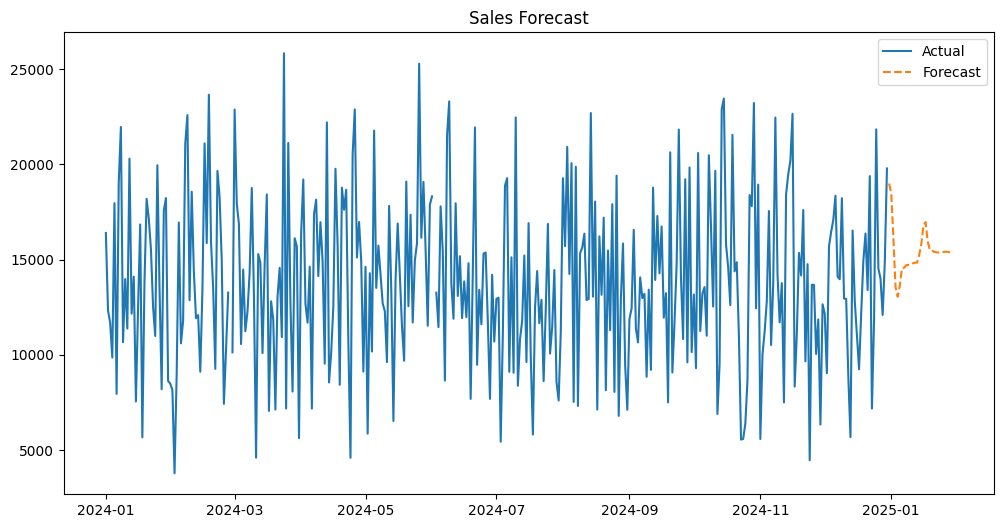

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/Users/pranavsbharadwaj/Desktop/business_suite_datasets/shopping_mall_sales_dataset.csv"

best_model_name, results, df = run_forecast_pipeline(file_path)

print("Best Model Used:", best_model_name)

model = results[best_model_name][1]
target_col = df.columns[0]

future_steps = 30

# =========================
# ARIMA
# =========================
if best_model_name == "ARIMA":
    forecast = model.forecast(steps=future_steps)

# =========================
# PROPHET
# =========================
elif best_model_name == "Prophet":
    prophet_df = df.reset_index()
    prophet_df.columns = ['ds','y']

    model.fit(prophet_df)
    future = model.make_future_dataframe(periods=future_steps)
    forecast_df = model.predict(future)

    forecast = forecast_df['yhat'][-future_steps:].values

# =========================
# XGBOOST
# =========================
elif best_model_name == "XGBoost":

    df_feat = df.copy()

    df_feat['month'] = df_feat.index.month
    df_feat['year'] = df_feat.index.year
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['quarter'] = df_feat.index.quarter
    df_feat['weekofyear'] = df_feat.index.isocalendar().week

    df_feat['lag1'] = df_feat[target_col].shift(1)
    df_feat['lag2'] = df_feat[target_col].shift(2)
    df_feat['lag3'] = df_feat[target_col].shift(3)

    df_feat['rolling_mean_3'] = df_feat[target_col].rolling(3).mean()
    df_feat['rolling_mean_6'] = df_feat[target_col].rolling(6).mean()
    df_feat['rolling_std_3'] = df_feat[target_col].rolling(3).std()
    df_feat['diff1'] = df_feat[target_col].diff()

    df_feat = df_feat.dropna()

    X = df_feat[['month','year','dayofweek','quarter','weekofyear',
                 'lag1','lag2','lag3',
                 'rolling_mean_3','rolling_mean_6',
                 'rolling_std_3','diff1']]

    last_row = df_feat.iloc[-1:].copy()
    current_input = last_row[X.columns].copy()

    preds = []
    current_date = df_feat.index[-1]

    for _ in range(future_steps):
        pred = model.predict(current_input)[0]
        preds.append(pred)

        current_date += pd.Timedelta(days=1)

        current_input['month'] = current_date.month
        current_input['year'] = current_date.year
        current_input['dayofweek'] = current_date.dayofweek
        current_input['quarter'] = current_date.quarter
        current_input['weekofyear'] = current_date.isocalendar().week

        current_input['lag3'] = current_input['lag2']
        current_input['lag2'] = current_input['lag1']
        current_input['lag1'] = pred

        current_input['rolling_mean_3'] = (
            current_input['lag1'] + current_input['lag2'] + current_input['lag3']
        ) / 3

        current_input['rolling_mean_6'] = current_input['rolling_mean_3']

        current_input['rolling_std_3'] = abs(
            current_input['lag1'] - current_input['rolling_mean_3']
        )

        current_input['diff1'] = current_input['lag1'] - current_input['lag2']

    forecast = preds

# =========================
# PLOT
# =========================
df = df.asfreq('D')

plt.figure(figsize=(12,6))
plt.plot(df.index, df[target_col], label="Actual")
future_dates = pd.date_range(start=df.index[-1], periods=future_steps+1, freq='D')[1:]
plt.plot(future_dates, forecast, label="Forecast", linestyle='dashed')

plt.legend()
plt.title("Sales Forecast")
plt.show()